In [2]:
import os
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from reedsolo import RSCodec

import matplotlib.pyplot as plt

import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from rs.channels import qsc_erasure_channel
from rs.dataset_gen import bytes_to_bits, get_zero_mask, RSPositionDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

from torchvision.ops import sigmoid_focal_loss
from rs.decoder import HybridDecoder

Device: cpu


In [3]:
class PositionPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        layers = []

        layers.append(nn.Linear(511, 512))
        layers.append(nn.BatchNorm1d(512))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.1))

        for _ in range(3):
            layers.append(nn.Linear(512, 512))
            layers.append(nn.BatchNorm1d(512))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
        
        layers.append(nn.Linear(512, 255))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [4]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.2, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        return sigmoid_focal_loss(inputs, targets, alpha=self.alpha, gamma=self.gamma, reduction='mean')
    

In [5]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, p_err, p_erase, num_samples=1000):
    model.eval()
    rsc = RSCodec(32)
    hybrid = HybridDecoder(model)
    
    classic_success = 0
    hybrid_success = 0
    classic_hint_success = 0
    
    for _ in range(num_samples):
        msg = os.urandom(223)
        codeword = rsc.encode(msg)
        noisy, erasure_pos = qsc_erasure_channel(codeword, p_err, p_erase)
        
        try:
            decoded, _, _ = rsc.decode(noisy)
            if bytes(decoded) == msg:
                classic_success += 1
        except:
            pass
        
        try:
            decoded, _, _ = rsc.decode(noisy, erase_pos=erasure_pos)
            if bytes(decoded) == msg:
                classic_hint_success += 1
        except:
            pass
        
        decoded = hybrid.decode(noisy, device)
        if decoded == msg:
            hybrid_success += 1
    
    return {
        'classic': classic_success / num_samples,
        'hybrid': hybrid_success / num_samples,
        'classic_hint': classic_hint_success / num_samples
    }

In [9]:
P_ERR = 0.02
P_ERASE = 0.06
TRAIN_SIZE = 50000
EPOCHS = 30

print('Generating dataset...')
dataset = RSPositionDataset(TRAIN_SIZE, P_ERR, P_ERASE)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

model = PositionPredictor().to(device)
criterion = FocalLoss(alpha=0.2, gamma=1.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print('Training...')
for epoch in range(EPOCHS):
    loss = train_epoch(model, loader, criterion, optimizer)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}')

Generating dataset...
Training...
Epoch 5/30, Loss: 0.0196
Epoch 10/30, Loss: 0.0176
Epoch 15/30, Loss: 0.0168
Epoch 20/30, Loss: 0.0164
Epoch 25/30, Loss: 0.0160
Epoch 30/30, Loss: 0.0157


In [ ]:
print("=== Tuning threshold ===")
print(f"{'Threshold':<12} {'Hybrid':<10} {'Pred':<8}")
print("-" * 30)

model.eval()

for threshold in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    hybrid = HybridDecoder(model, threshold=threshold)
    
    rsc = RSCodec(32)
    success = 0
    total_pred = 0
    
    for _ in range(1000):
        msg = os.urandom(223)
        codeword = rsc.encode(msg)
        noisy, _ = qsc_erasure_channel(codeword, P_ERR, 0.06)
        
        decoded = hybrid.decode(noisy, device)
        if decoded == msg:
            success += 1
    
    sample_input, _ = dataset[0]
    x = torch.tensor(sample_input).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(x))
        preds = (probs > threshold).sum().item()
    
    print(f"{threshold:<12} {success/1000:<10.3f} {preds:<8}")

=== Tuning threshold ===
Threshold    Hybrid     Pred    
------------------------------


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 512])

In [11]:
p_erase_values = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14]
results = []

print(f'{"p_erase":<10} {"Classic":<10} {"Hybrid":<10} {"Cls+hint":<10}')
print('-' * 40)

for p_erase in p_erase_values:
    r = evaluate(model, P_ERR, p_erase)
    r['p_erase'] = p_erase
    results.append(r)
    print(f'{p_erase:<10} {r["classic"]:<10.3f} {r["hybrid"]:<10.3f} {r["classic_hint"]:<10.3f}')

p_erase    Classic    Hybrid     Cls+hint  
----------------------------------------
0.02       0.967      0.996      0.999     
0.04       0.652      0.963      0.979     
0.06       0.181      0.816      0.889     
0.08       0.036      0.453      0.620     
0.1        0.002      0.163      0.313     
0.12       0.000      0.038      0.089     
0.14       0.000      0.006      0.018     


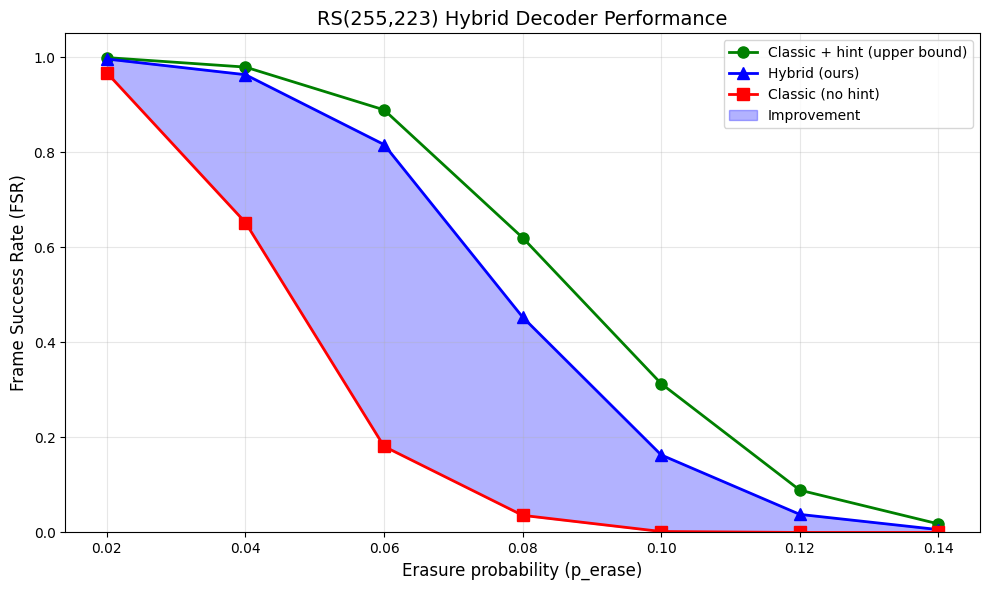

In [12]:
p_erase = [r['p_erase'] for r in results]
classic = [r['classic'] for r in results]
hybrid = [r['hybrid'] for r in results]
classic_hint = [r['classic_hint'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(p_erase, classic_hint, 'g-o', linewidth=2, markersize=8, label='Classic + hint (upper bound)')
plt.plot(p_erase, hybrid, 'b-^', linewidth=2, markersize=8, label='Hybrid (ours)')
plt.plot(p_erase, classic, 'r-s', linewidth=2, markersize=8, label='Classic (no hint)')

plt.fill_between(p_erase, classic, hybrid, alpha=0.3, color='blue', label='Improvement')

plt.xlabel('Erasure probability (p_erase)', fontsize=12)
plt.ylabel('Frame Success Rate (FSR)', fontsize=12)
plt.title('RS(255,223) Hybrid Decoder Performance', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()